In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Create sample data for 500 students
n = 500

attendance = np.random.uniform(40, 100, n)
study_hours = np.random.uniform(0.5, 8, n)
internal_marks = np.random.uniform(20, 100, n)

# Generate illustrative final marks
noise = np.random.normal(0, 4, n)

final_marks = (
    0.25 * attendance
    + 2.5 * study_hours
    + 0.55 * internal_marks
    + noise
)

# Keep marks within 0-100
final_marks = np.clip(final_marks, 0, 100)

df = pd.DataFrame({
    "Attendance": attendance,
    "Study_Hours": study_hours,
    "Internal_Marks": internal_marks,
    "Final_Marks": final_marks
})

df = df.round(2)

print("Dataset created successfully!")
print(df.head())
print("\nDataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Dataset created successfully!
   Attendance  Study_Hours  Internal_Marks  Final_Marks
0       62.47         5.74           34.81        39.11
1       97.04         4.52           63.35        79.57
2       83.92         2.82           89.84        71.88
3       75.92         6.60           78.58        72.12
4       49.36         5.64           84.52        77.01

Dataset shape: (500, 4)

Missing values:
Attendance        0
Study_Hours       0
Internal_Marks    0
Final_Marks       0
dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Input features
X = df[[
    "Attendance",
    "Study_Hours",
    "Internal_Marks"
]]

# Target variable
y = df["Final_Marks"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize input features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Data preprocessing completed!")

Training samples: 400
Testing samples: 100
Data preprocessing completed!


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(42)

# Create ANN model
model = Sequential([
    Dense(16, activation="relu", input_shape=(3,)),
    Dense(8, activation="relu"),
    Dense(1, activation="linear")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

# Display model structure
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

print("ANN training completed!")

ANN training completed!


In [5]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

# Predict test-set marks
y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
MAE:  4.62
RMSE: 5.67
R2 Score: 0.852


In [6]:
# Example of a new student
new_student = pd.DataFrame({
    "Attendance": [85],
    "Study_Hours": [4],
    "Internal_Marks": [78]
})

# Apply the same scaler used during training
new_student_scaled = scaler.transform(new_student)

# Predict final marks
predicted_marks = model.predict(
    new_student_scaled, verbose=0
)[0][0]

predicted_marks = np.clip(predicted_marks, 0, 100)

print("Student Details:")
print(new_student)

print(f"\nPredicted Final Marks: {predicted_marks:.2f}")

Student Details:
   Attendance  Study_Hours  Internal_Marks
0          85            4              78

Predicted Final Marks: 71.65


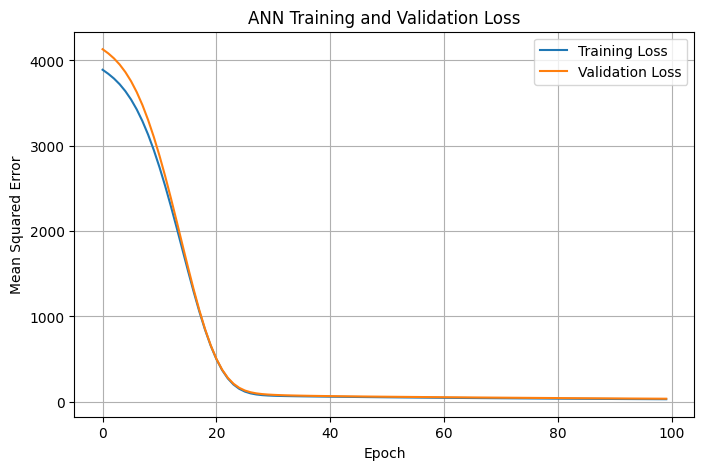

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()